In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


C:\Users\manis\AppData\Local\Temp\ipykernel_22484\3792736820.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\manis\AppData\Local\Temp\ipykernel_22484\3792736820.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


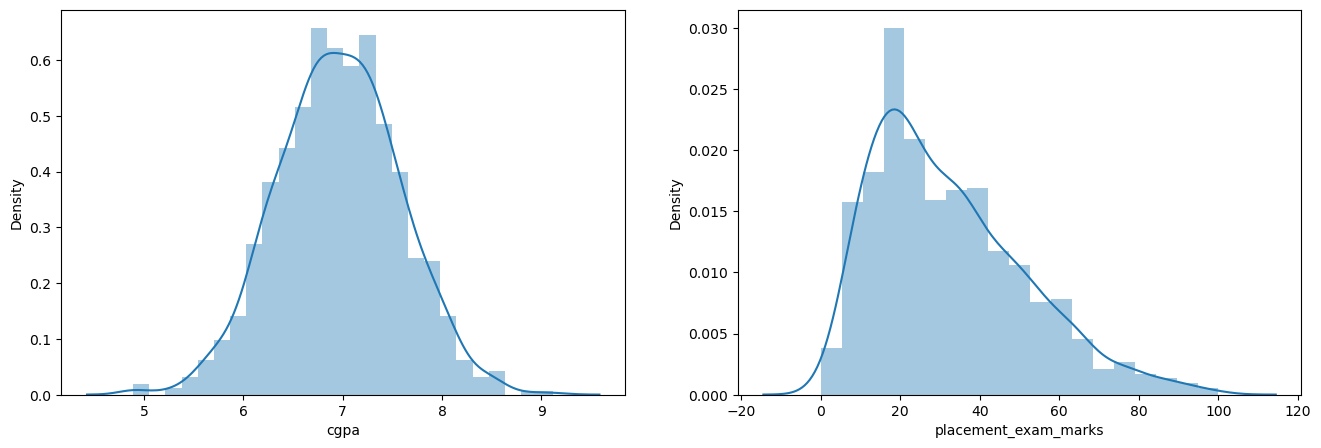

In [4]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

# now we think on placement mark analysis

In [5]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

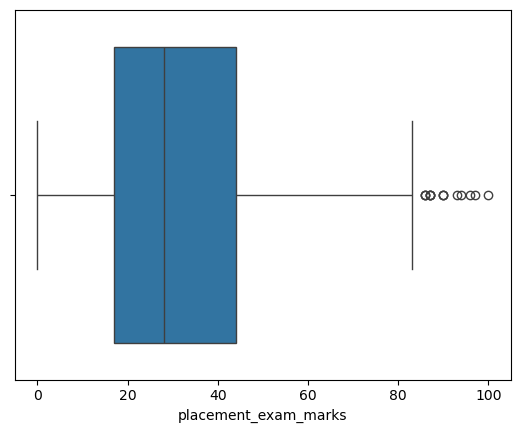

In [8]:
sns.boxplot(x=df['placement_exam_marks'])

# only now we have to fix this outliers 

![My Image](./outliers.png))

# Now we are calculating percentile 
 * 25%tile 
 * 75%tile 

In [10]:
# Finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [12]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 

44.0
17.0


# iqr = q3- Q1

In [14]:
iqr = percentile75-  percentile25 
iqr

np.float64(27.0)

# finding limit upper and lower 

In [16]:
upperlimt = percentile75 + 1.5*iqr
lowerlimt = percentile25-1.5*iqr


np.float64(-23.5)

In [17]:
print(upperlimt)
print(lowerlimt)

84.5
-23.5


# Finding the outlier

In [19]:
df[df['placement_exam_marks'] > upperlimt]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [ ]:
df[df['placement_exam_marks'] < lowerlimt]

,cgpa,placement_exam_marks,placed


## Trimming

In [ ]:
new_df = df[df["placement_exam_marks"]<upperlimt] # remove 15 higher value 

# now new shap loading 

In [23]:
print(new_df.shape)
print(df.shape)

(985, 3)
(1000, 3)


<Axes: xlabel='placement_exam_marks'>

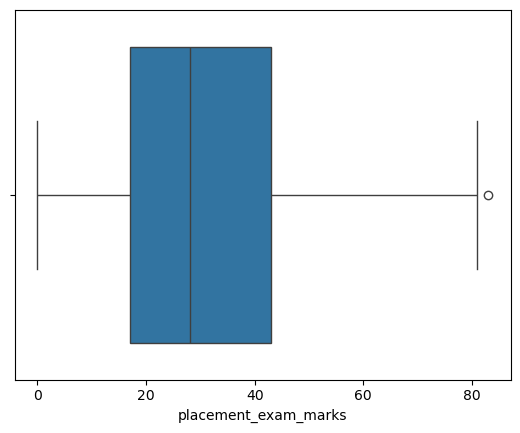

In [24]:
sns.boxplot(x=new_df['placement_exam_marks'])

C:\Users\manis\AppData\Local\Temp\ipykernel_22484\965294388.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\manis\AppData\Local\Temp\ipykernel_22484\965294388.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['placement_exam_marks'])


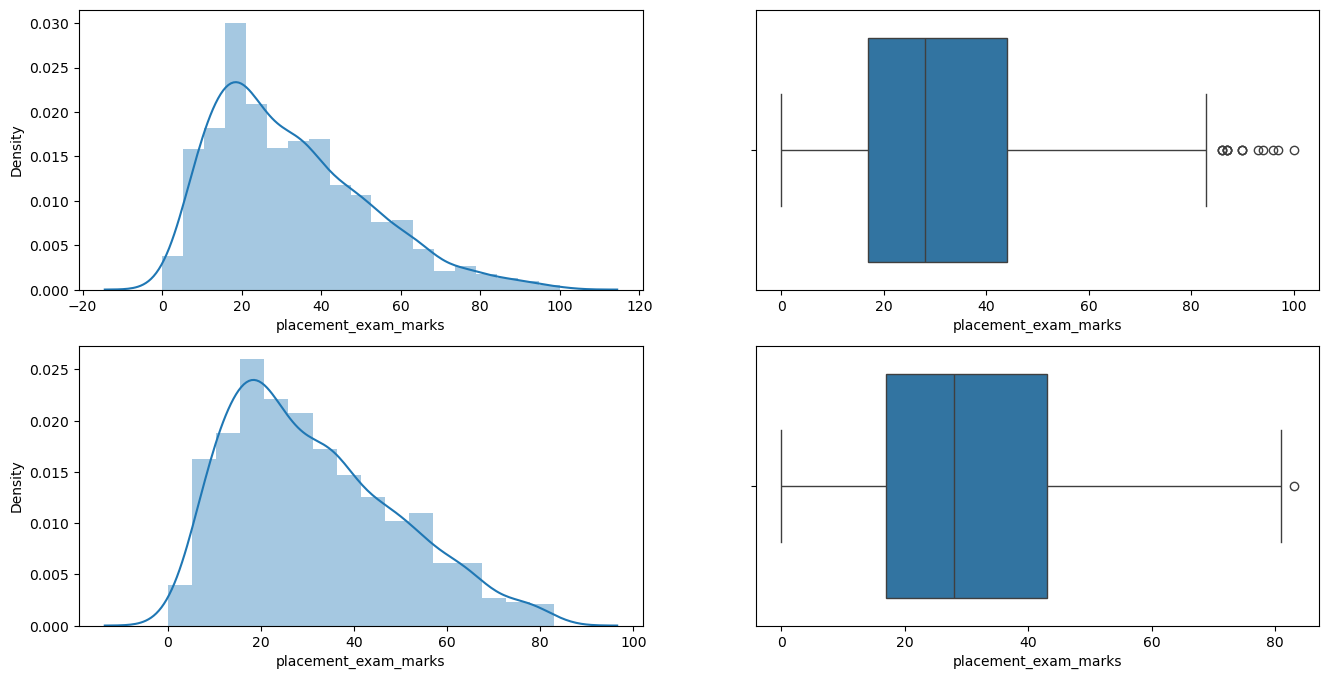

In [27]:
# Comparing

plt.figure(figsize=(16,8)) # figure size
plt.subplot(2,2,1) # plot number
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(x=new_df['placement_exam_marks'])

plt.show()

# capping 
n.where =  x y z   
x for upperlimit check   
y for lower limit check   
z = keep the value same      

In [30]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upperlimt,
    upperlimt,
    np.where(
        new_df_cap['placement_exam_marks'] <lowerlimt,
        lowerlimt,
        new_df_cap['placement_exam_marks']
    )
)

C:\Users\manis\AppData\Local\Temp\ipykernel_22484\958548826.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])
C:\Users\manis\AppData\Local\Temp\ipykernel_22484\958548826.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['placement_exam_marks'])


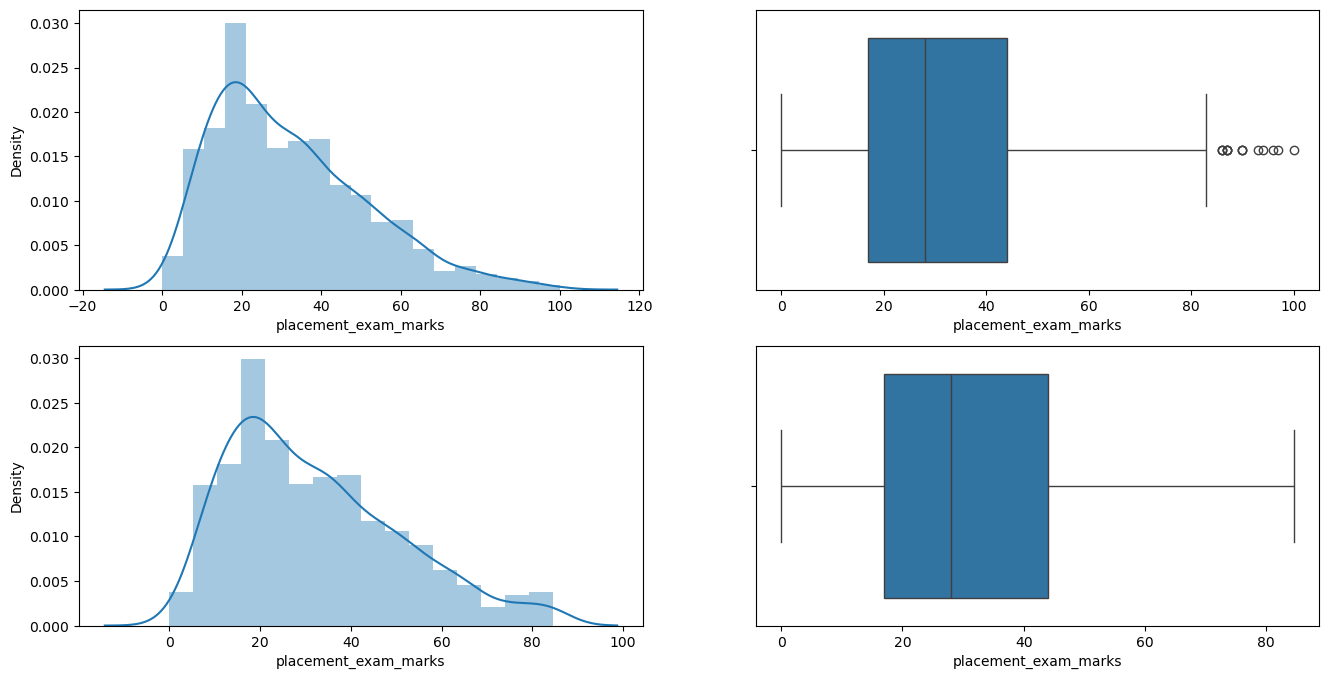

In [32]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(x=new_df_cap['placement_exam_marks'])

plt.show()

 * percentile25 = df['Glucose'].quantile(0.25) [ ]
 * percentile75 = df['Glucose'].quantile(0.75) [ ]

   
 * iqr = percentile75-  percentile25 
 * iqr  

 *  upperlimt = percentile75 + 1.5*iqr
 * lowerlimt = percentile25-1.5*iqr
 * print(upperlimt, lowerlimt)

 * df[df['Glucose'] > upperlimt]
 * df[df['Glucose'] < lowerlimt]
